Feature Extraction for Cat Distress Detection

Goal: Convert preprocessed audio arrays into feature vectors for ML models

Features to Extract
1. **MFCCs** - Standard for audio classification
2. **Spectral features** - Frequency domain characteristics
3. **Temporal features** - Time domain patterns
4. **Statistical aggregations** - Mean, std, min, max of above

In [1]:
# Google Colab Setup
try:
    import google.colab
    from google.colab import drive
    drive.mount('/content/drive')
    print("✓ Google Drive mounted")
except:
    print("✓ Running locally")

GDRIVE_BASE = '/content/drive/MyDrive/Electric Sheep/Beliz - EDA/Erin_PreprocessingandNotes'

# %%
# Install packages (using soundfile to avoid librosa issues)
print("Installing packages...")
!pip install -q soundfile scipy resampy
print("✓ Packages installed")

# %%
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Try importing librosa for feature extraction ONLY
try:
    import librosa
    LIBROSA_AVAILABLE = True
    print(f"✓ Librosa available: {librosa.__version__}")
except:
    LIBROSA_AVAILABLE = False
    print("Librosa not available - will use alternative methods")

# For manual feature extraction if librosa fails
from scipy import signal, fft
from scipy.stats import skew, kurtosis

print("✓ All imports successful")

# %%
# Setup paths
PROJECT_ROOT = Path(GDRIVE_BASE)
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
FEATURES_DIR = DATA_DIR / "features2"
FIGURES_DIR = PROJECT_ROOT / "figures2"

# Create features directory
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"✓ Features will be saved to: {FEATURES_DIR}")

# %%
# Load preprocessed metadata
metadata_path = DATA_DIR / "metadata_preprocessed.csv"

if not metadata_path.exists():
    print(f"Preprocessed metadata not found: {metadata_path}")
    print("Please run preprocessing first!")
else:
    df = pd.read_csv(metadata_path)
    df_clean = df[df['preprocessed'] == True].copy()

    print(f"✓ Loaded metadata: {len(df_clean)} preprocessed files")
    print(f"  Contexts: {df_clean['context'].value_counts().to_dict()}")
    print(f"  Distress labels: {df_clean['distress_label'].value_counts().to_dict()}")

# Get preprocessing parameters
import json
splits_info_path = DATA_DIR / "splits_info.json"
if splits_info_path.exists():
    with open(splits_info_path, 'r') as f:
        splits_info = json.load(f)
    TARGET_SR = splits_info['target_sr']
    TARGET_LENGTH = splits_info['target_length']
    print(f"✓ Loaded preprocessing params: SR={TARGET_SR} Hz, Length={TARGET_LENGTH} samples")
else:
    # Default values
    TARGET_SR = 22050
    TARGET_LENGTH = int(3.0 * TARGET_SR)  # Adjust based on your preprocessing
    print(f"Using default params: SR={TARGET_SR} Hz, Length={TARGET_LENGTH} samples")


Mounted at /content/drive
✓ Google Drive mounted
Installing packages...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 57.9 MB/s eta 0:00:00
✓ Packages installed
✓ Librosa available: 0.11.0
✓ All imports successful
✓ Features will be saved to: /content/drive/MyDrive/Electric Sheep/Beliz - EDA/Erin_PreprocessingandNotes/data/features2
Preprocessed metadata not found: /content/drive/MyDrive/Electric Sheep/Beliz - EDA/Erin_PreprocessingandNotes/data/metadata_preprocessed.csv
Please run preprocessing first!
Using default params: SR=22050 Hz, Length=66150 samples


In [2]:
def extract_mfcc_features(y, sr=22050, n_mfcc=13):
    """
    Extract MFCC features.

    MFCCs capture the timbral characteristics of audio.
    Standard for speech and animal vocalization classification.

    Args:
        y: audio signal
        sr: sample rate
        n_mfcc: number of MFCCs to extract (default 13)

    Returns:
        dict of MFCC statistics
    """
    features = {}

    try:
        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

        # Statistics for each MFCC coefficient
        for i in range(n_mfcc):
            features[f'mfcc_{i}_mean'] = np.mean(mfccs[i])
            features[f'mfcc_{i}_std'] = np.std(mfccs[i])
            features[f'mfcc_{i}_min'] = np.min(mfccs[i])
            features[f'mfcc_{i}_max'] = np.max(mfccs[i])

        # Delta MFCCs (rate of change)
        mfccs_delta = librosa.feature.delta(mfccs)
        for i in range(n_mfcc):
            features[f'mfcc_delta_{i}_mean'] = np.mean(mfccs_delta[i])
            features[f'mfcc_delta_{i}_std'] = np.std(mfccs_delta[i])

    except Exception as e:
        print(f"Error extracting MFCCs: {e}")
        # Fill with NaN if extraction fails
        for i in range(n_mfcc):
            features[f'mfcc_{i}_mean'] = np.nan
            features[f'mfcc_{i}_std'] = np.nan
            features[f'mfcc_{i}_min'] = np.nan
            features[f'mfcc_{i}_max'] = np.nan
            features[f'mfcc_delta_{i}_mean'] = np.nan
            features[f'mfcc_delta_{i}_std'] = np.nan

    return features

# %%
def extract_spectral_features(y, sr=22050):
    """
    Extract spectral (frequency-domain) features.

    These capture how the frequency content changes over time:
    - Spectral centroid: "brightness" of sound
    - Spectral bandwidth: spread of frequencies
    - Spectral rolloff: frequency below which X% of energy is contained
    - Spectral contrast: difference between peaks and valleys
    - Zero crossing rate: how often signal changes sign (noisiness)

    Args:
        y: audio signal
        sr: sample rate

    Returns:
        dict of spectral features
    """
    features = {}

    try:
        # Spectral centroid (perceived brightness)
        spectral_centroids = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
        features['spectral_centroid_mean'] = np.mean(spectral_centroids)
        features['spectral_centroid_std'] = np.std(spectral_centroids)
        features['spectral_centroid_min'] = np.min(spectral_centroids)
        features['spectral_centroid_max'] = np.max(spectral_centroids)

        # Spectral bandwidth (spread of frequencies)
        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
        features['spectral_bandwidth_mean'] = np.mean(spectral_bandwidth)
        features['spectral_bandwidth_std'] = np.std(spectral_bandwidth)

        # Spectral rolloff (frequency below which 85% of energy is)
        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)[0]
        features['spectral_rolloff_mean'] = np.mean(spectral_rolloff)
        features['spectral_rolloff_std'] = np.std(spectral_rolloff)

        # Spectral contrast (difference between peaks and valleys)
        spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        for i in range(spectral_contrast.shape[0]):
            features[f'spectral_contrast_{i}_mean'] = np.mean(spectral_contrast[i])

        # Zero crossing rate (how noisy/percussive)
        zcr = librosa.feature.zero_crossing_rate(y)[0]
        features['zcr_mean'] = np.mean(zcr)
        features['zcr_std'] = np.std(zcr)

    except Exception as e:
        print(f"Error extracting spectral features: {e}")
        features['spectral_centroid_mean'] = np.nan
        features['spectral_centroid_std'] = np.nan
        features['spectral_bandwidth_mean'] = np.nan
        features['spectral_rolloff_mean'] = np.nan
        features['zcr_mean'] = np.nan

    return features

# %%
def extract_temporal_features(y, sr=22050):
    """
    Extract temporal (time-domain) features.

    These capture energy and amplitude characteristics:
    - RMS energy: overall loudness
    - Energy statistics: distribution of energy over time

    Args:
        y: audio signal
        sr: sample rate

    Returns:
        dict of temporal features
    """
    features = {}

    try:
        # RMS energy (loudness)
        rms = librosa.feature.rms(y=y)[0]
        features['rms_mean'] = np.mean(rms)
        features['rms_std'] = np.std(rms)
        features['rms_min'] = np.min(rms)
        features['rms_max'] = np.max(rms)

        # Amplitude envelope statistics
        features['amplitude_mean'] = np.mean(np.abs(y))
        features['amplitude_std'] = np.std(y)
        features['amplitude_min'] = np.min(y)
        features['amplitude_max'] = np.max(y)
        features['amplitude_range'] = np.max(y) - np.min(y)

        # Energy in different parts of the signal
        # Divide into 4 quarters and measure energy
        quarter_len = len(y) // 4
        for i in range(4):
            start = i * quarter_len
            end = (i + 1) * quarter_len if i < 3 else len(y)
            quarter_energy = np.sum(y[start:end]**2)
            features[f'energy_quarter_{i+1}'] = quarter_energy

    except Exception as e:
        print(f"Error extracting temporal features: {e}")
        features['rms_mean'] = np.nan
        features['amplitude_mean'] = np.nan

    return features

# %%
def extract_pitch_features(y, sr=22050):
    """
    Extract pitch-related features.

    Fundamental frequency (pitch) can indicate distress:
    - Distressed cats may have higher or more variable pitch

    Args:
        y: audio signal
        sr: sample rate

    Returns:
        dict of pitch features
    """
    features = {}

    try:
        # Extract fundamental frequency (pitch)
        pitches, magnitudes = librosa.piptrack(y=y, sr=sr, fmin=100, fmax=1000)

        # Get pitch values (only where magnitude is significant)
        pitch_values = []
        for t in range(pitches.shape[1]):
            index = magnitudes[:, t].argmax()
            pitch = pitches[index, t]
            if pitch > 0:  # Valid pitch
                pitch_values.append(pitch)

        if len(pitch_values) > 0:
            features['pitch_mean'] = np.mean(pitch_values)
            features['pitch_std'] = np.std(pitch_values)
            features['pitch_min'] = np.min(pitch_values)
            features['pitch_max'] = np.max(pitch_values)
            features['pitch_range'] = np.max(pitch_values) - np.min(pitch_values)
        else:
            features['pitch_mean'] = 0
            features['pitch_std'] = 0
            features['pitch_min'] = 0
            features['pitch_max'] = 0
            features['pitch_range'] = 0

    except Exception as e:
        print(f"Error extracting pitch features: {e}")
        features['pitch_mean'] = np.nan
        features['pitch_std'] = np.nan

    return features

# %%
def extract_all_features(y, sr=22050):
    """
    Extract all features from an audio signal.

    Args:
        y: audio signal (numpy array)
        sr: sample rate

    Returns:
        dict with all features
    """
    all_features = {}

    # Extract each feature group
    all_features.update(extract_mfcc_features(y, sr))
    all_features.update(extract_spectral_features(y, sr))
    all_features.update(extract_temporal_features(y, sr))
    all_features.update(extract_pitch_features(y, sr))

    return all_features

# Test Feature Extraction on One File

print("=" * 70)
print("TESTING FEATURE EXTRACTION")
print("=" * 70)

# Load one preprocessed file
test_row = df_clean.sample(1).iloc[0]
test_file_path = test_row['preprocessed_file_path']

print(f"\nTest file: {test_row['filename']}")
print(f"Context: {test_row['context']}")
print(f"Distress label: {test_row['distress_label']}")

# Load preprocessed audio
y_test = np.load(test_file_path)
print(f"\nLoaded audio:")
print(f"  Shape: {y_test.shape}")
print(f"  Duration: {len(y_test) / TARGET_SR:.3f}s")

# Extract features
print(f"\nExtracting features...")
features_test = extract_all_features(y_test, sr=TARGET_SR)

print(f"\n✓ Extracted {len(features_test)} features")
print(f"\nSample features:")
for i, (name, value) in enumerate(list(features_test.items())[:10]):
    print(f"  {name}: {value:.4f}")


TESTING FEATURE EXTRACTION


NameError: name 'df_clean' is not defined

In [ ]:
# Extract Features for All Files


print("\n" + "=" * 70)
print("EXTRACTING FEATURES FOR ALL FILES")
print("=" * 70)
print(f"\nTotal files: {len(df_clean)}")
print(f"Estimated time: ~{len(df_clean) * 3 / 60:.1f} minutes\n")

# %%
all_features_list = []
failed_extractions = []

for idx, row in tqdm(df_clean.iterrows(), total=len(df_clean), desc="Extracting features"):
    try:
        # Load preprocessed audio
        y = np.load(row['preprocessed_file_path'])

        # Extract features
        features = extract_all_features(y, sr=TARGET_SR)

        # Add metadata
        features['filename'] = row['filename']
        features['cat_id'] = row['cat_id']
        features['context'] = row['context']
        features['distress_label'] = row['distress_label']
        features['breed'] = row['breed']
        features['sex'] = row['sex']
        features['split'] = row.get('split', 'unknown')  # If you did train/val/test split
        features['index'] = idx

        all_features_list.append(features)

    except Exception as e:
        print(f"\n  Error with {row['filename']}: {e}")
        failed_extractions.append(idx)

    # Checkpoint every 100 files
    if (len(all_features_list) + 1) % 100 == 0:
        temp_df = pd.DataFrame(all_features_list)
        temp_df.to_csv(FEATURES_DIR / f'features_checkpoint_{len(all_features_list)}.csv', index=False)

# %%
# Create features DataFrame
df_features = pd.DataFrame(all_features_list)

print(f"\n{'='*70}")
print("FEATURE EXTRACTION COMPLETE")
print(f"{'='*70}")

print(f"\n✓ Successfully extracted: {len(df_features)} files")
print(f"Failed: {len(failed_extractions)} files")

if len(failed_extractions) > 0:
    print(f"\nFailed indices: {failed_extractions}")

print(f"\nFeature matrix shape: {df_features.shape}")
print(f"  Rows (samples): {df_features.shape[0]}")
print(f"  Columns (features + metadata): {df_features.shape[1]}")

# Analyze and Save Features

# Separate features from metadata
metadata_cols = ['filename', 'cat_id', 'context', 'distress_label', 'breed', 'sex', 'split', 'index']
feature_cols = [col for col in df_features.columns if col not in metadata_cols]

print(f"\n{'='*70}")
print("FEATURE SUMMARY")
print(f"{'='*70}")
print(f"\nTotal features extracted: {len(feature_cols)}")

# Group features by type
mfcc_features = [col for col in feature_cols if 'mfcc' in col]
spectral_features = [col for col in feature_cols if 'spectral' in col or 'zcr' in col]
temporal_features = [col for col in feature_cols if 'rms' in col or 'amplitude' in col or 'energy' in col]
pitch_features = [col for col in feature_cols if 'pitch' in col]

print(f"\nFeature groups:")
print(f"  MFCC features: {len(mfcc_features)}")
print(f"  Spectral features: {len(spectral_features)}")
print(f"  Temporal features: {len(temporal_features)}")
print(f"  Pitch features: {len(pitch_features)}")


# Check for missing values
missing_counts = df_features[feature_cols].isna().sum()
features_with_missing = missing_counts[missing_counts > 0]

if len(features_with_missing) > 0:
    print(f"\n⚠️  Features with missing values:")
    print(features_with_missing)

    # Fill missing values with median (common practice)
    print(f"\nFilling missing values with feature medians...")
    for col in features_with_missing.index:
        median_val = df_features[col].median()
        df_features[col].fillna(median_val, inplace=True)

    print(f"✓ Missing values handled")
else:
    print(f"\n✓ No missing values")


# Check feature statistics
print(f"\n{'='*70}")
print("FEATURE STATISTICS")
print(f"{'='*70}")

print(f"\nSample of extracted features:")
print(df_features[feature_cols].describe().iloc[:, :5])  # Show first 5 features


# Save features
features_csv_path = FEATURES_DIR / "features_all.csv"
df_features.to_csv(features_csv_path, index=False)

print(f"\n✓ Saved complete features: {features_csv_path}")

# Also save separate train/val/test if splits exist
if 'split' in df_features.columns and df_features['split'].nunique() > 1:
    for split in ['train', 'val', 'test']:
        split_df = df_features[df_features['split'] == split]
        if len(split_df) > 0:
            split_path = FEATURES_DIR / f"features_{split}.csv"
            split_df.to_csv(split_path, index=False)
            print(f"✓ Saved {split} features: {split_path} ({len(split_df)} samples)")



EXTRACTING FEATURES FOR ALL FILES

Total files: 440
Estimated time: ~22.0 minutes



Extracting features: 100%|██████████| 440/440 [03:51<00:00,  1.90it/s]



FEATURE EXTRACTION COMPLETE

✓ Successfully extracted: 440 files
Failed: 0 files

Feature matrix shape: (440, 121)
  Rows (samples): 440
  Columns (features + metadata): 121

FEATURE SUMMARY

Total features extracted: 113

Feature groups:
  MFCC features: 78
  Spectral features: 17
  Temporal features: 13
  Pitch features: 5

✓ No missing values

FEATURE STATISTICS

Sample of extracted features:
       mfcc_0_mean  mfcc_0_std   mfcc_0_min  mfcc_0_max  mfcc_1_mean
count   440.000000  440.000000   440.000000  440.000000   440.000000
mean   -576.109704  119.651621  -734.996394 -349.410433    96.471781
std      88.813975   20.830812   107.444715  109.628900    24.065833
min    -793.600800   10.868894 -1017.266845 -633.086989    49.741962
25%    -634.566458  108.734080  -810.384057 -420.109040    79.666773
50%    -577.554220  119.830771  -724.056177 -329.254145    93.658113
75%    -513.286439  134.323043  -653.595083 -265.068879   109.061793
max    -325.140313  175.849237  -532.326828 -158


FEATURE VISUALIZATION


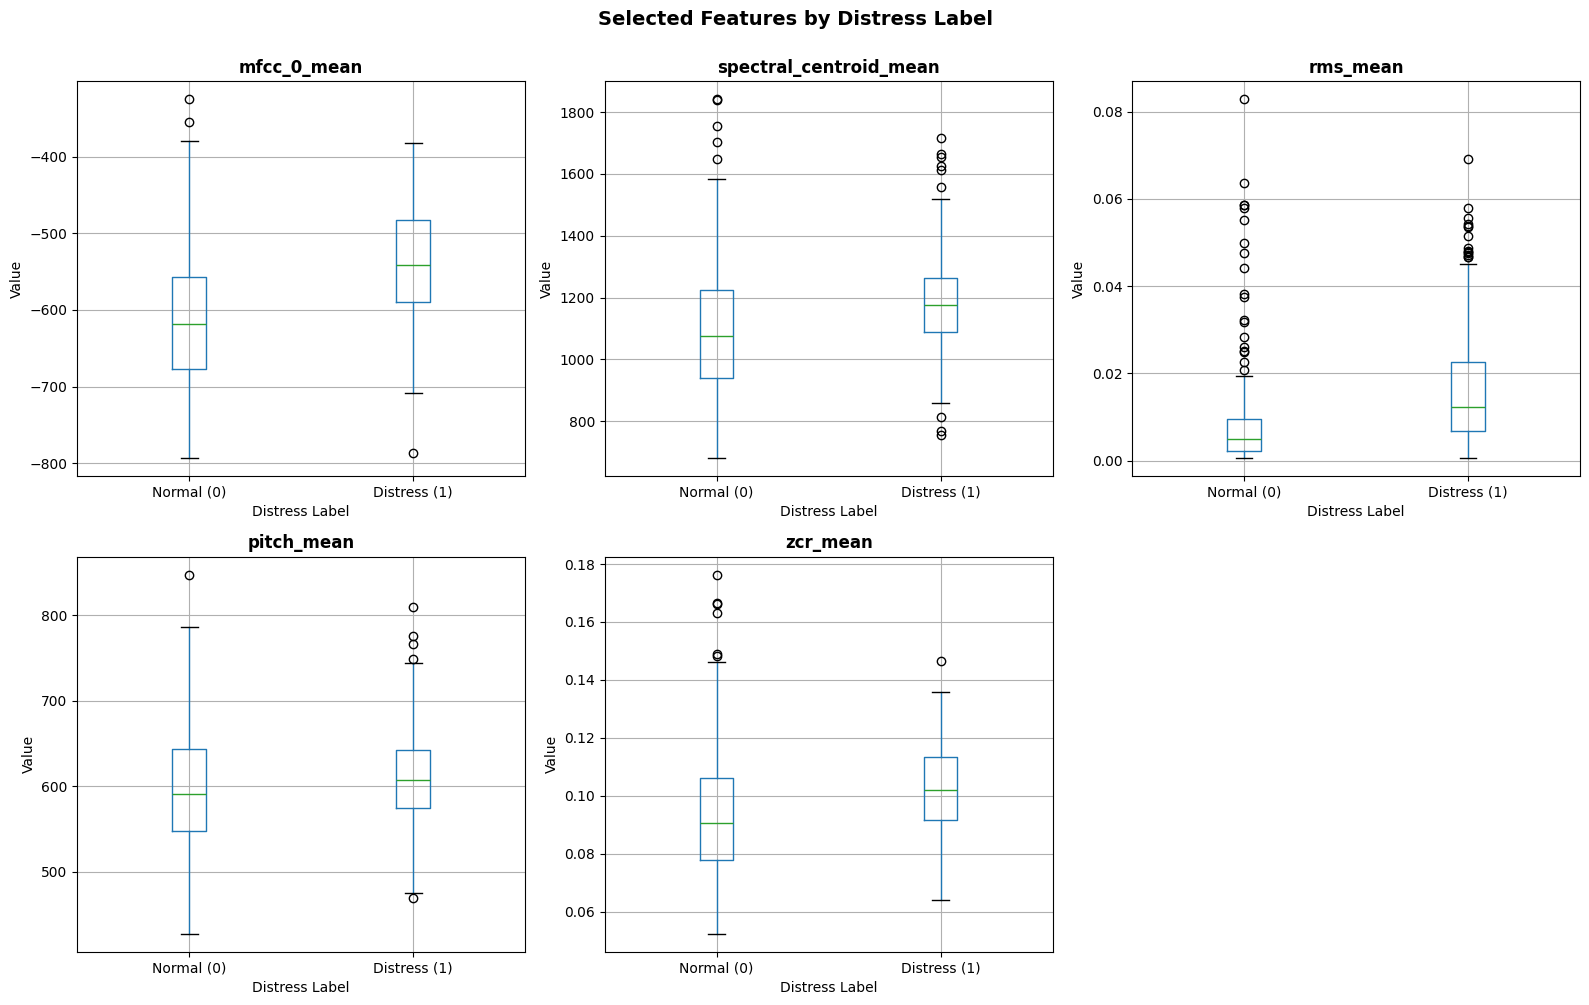


✓ Saved: features_01_by_distress_label.png

Calculating feature correlations with distress label...

Top 10 features correlated with distress:
  1. mfcc_0_min: 0.4450
  2. mfcc_delta_2_mean: 0.4355
  3. mfcc_0_mean: 0.4207
  4. mfcc_delta_4_mean: 0.4008
  5. mfcc_delta_0_mean: 0.3951
  6. mfcc_delta_1_mean: 0.3724
  7. mfcc_0_max: 0.3400
  8. spectral_contrast_3_mean: 0.3381
  9. mfcc_delta_8_mean: 0.3352
  10. rms_std: 0.3177


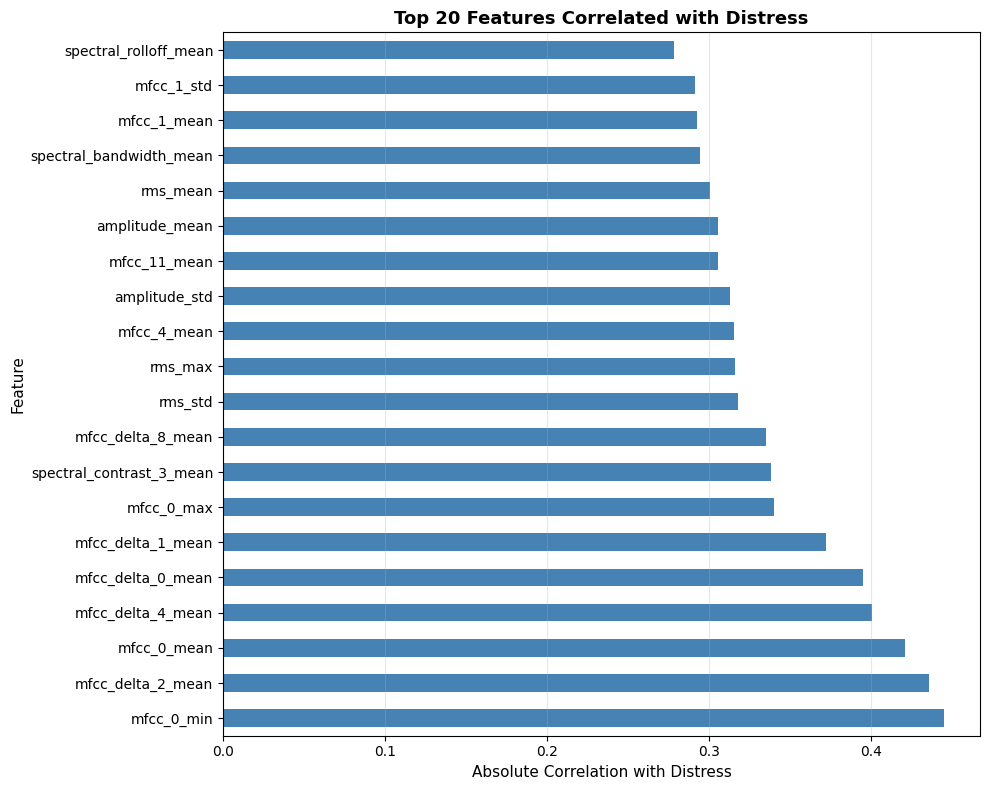

✓ Saved: features_02_correlations.png


In [ ]:
print(f"\n{'='*70}")
print("FEATURE VISUALIZATION")
print(f"{'='*70}")

# Select a few interesting features to visualize
interesting_features = [
    'mfcc_0_mean',  # First MFCC (overall spectral shape)
    'spectral_centroid_mean',  # Brightness
    'rms_mean',  # Loudness
    'pitch_mean',  # Fundamental frequency
    'zcr_mean'  # Noisiness
]

# Make sure these features exist
interesting_features = [f for f in interesting_features if f in df_features.columns]

if len(interesting_features) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for idx, feature in enumerate(interesting_features):
        if idx >= len(axes):
            break

        ax = axes[idx]

        # Box plot by distress label
        df_features.boxplot(column=feature, by='distress_label', ax=ax)
        ax.set_title(f'{feature}', fontweight='bold')
        ax.set_xlabel('Distress Label')
        ax.set_ylabel('Value')
        ax.set_xticklabels(['Normal (0)', 'Distress (1)'])
        plt.sca(ax)
        plt.xticks(rotation=0)

    # Hide extra subplots
    for idx in range(len(interesting_features), len(axes)):
        axes[idx].axis('off')

    plt.suptitle('Selected Features by Distress Label', fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'features_01_by_distress_label.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n✓ Saved: features_01_by_distress_label.png")

# %%
# Feature correlation with distress label
print(f"\nCalculating feature correlations with distress label...")

correlations = df_features[feature_cols].corrwith(df_features['distress_label']).abs().sort_values(ascending=False)

print(f"\nTop 10 features correlated with distress:")
for i, (feature, corr) in enumerate(correlations.head(10).items(), 1):
    print(f"  {i}. {feature}: {corr:.4f}")

# Visualize top correlations
fig, ax = plt.subplots(figsize=(10, 8))
correlations.head(20).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Absolute Correlation with Distress', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
ax.set_title('Top 20 Features Correlated with Distress', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'features_02_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: features_02_correlations.png")

In [ ]:
print("\n" + "=" * 70)
print("FEATURE EXTRACTION COMPLETE!")
print("=" * 70)

print(f"\n📊 FEATURE MATRIX SUMMARY")
print(f"{'='*70}")
print(f"Samples: {len(df_features)}")
print(f"Features: {len(feature_cols)}")
print(f"Feature groups:")
print(f"  - MFCC: {len(mfcc_features)}")
print(f"  - Spectral: {len(spectral_features)}")
print(f"  - Temporal: {len(temporal_features)}")
print(f"  - Pitch: {len(pitch_features)}")

print(f"\n💾 OUTPUT FILES")
print(f"{'='*70}")
print(f"1. Complete features: {features_csv_path}")
if 'split' in df_features.columns:
    print(f"2. Train features: {FEATURES_DIR / 'features_train.csv'}")
    print(f"3. Val features: {FEATURES_DIR / 'features_val.csv'}")
    print(f"4. Test features: {FEATURES_DIR / 'features_test.csv'}")
print(f"5. Visualizations: {FIGURES_DIR}/features_*.png")

print(f"\n📈 KEY INSIGHTS")
print(f"{'='*70}")
top_feature = correlations.index[0]
top_corr = correlations.iloc[0]
print(f"Most correlated feature: {top_feature} (r={top_corr:.4f})")
print(f"\nThis suggests {top_feature} is most predictive of distress")


FEATURE EXTRACTION COMPLETE!

📊 FEATURE MATRIX SUMMARY
Samples: 440
Features: 113
Feature groups:
  - MFCC: 78
  - Spectral: 17
  - Temporal: 13
  - Pitch: 5

💾 OUTPUT FILES
1. Complete features: /content/drive/MyDrive/Electric Sheep/Beliz - EDA/data/features/features_all.csv
2. Train features: /content/drive/MyDrive/Electric Sheep/Beliz - EDA/data/features/features_train.csv
3. Val features: /content/drive/MyDrive/Electric Sheep/Beliz - EDA/data/features/features_val.csv
4. Test features: /content/drive/MyDrive/Electric Sheep/Beliz - EDA/data/features/features_test.csv
5. Visualizations: /content/drive/MyDrive/Electric Sheep/Beliz - EDA/figures/features_*.png

📈 KEY INSIGHTS
Most correlated feature: mfcc_0_min (r=0.4450)

This suggests mfcc_0_min is most predictive of distress
